# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** I Putu Weda Sidhi Putra
- **Email:** ds014b6y0764@student.devacademy.id
- **ID Dicoding:** ds014b6y0764

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren jumlah pesanan (*total orders*) dan total pendapatan (*total revenue*) bulanan dari transaksi berstatus *delivered* pada E-Commerce Olist sepanjang periode Januari 2017 hingga Agustus 2018?
  - *Specific:* Fokus pada jumlah pesanan yang berhasil terkirim (*delivered*) dan total nilai transaksi produk.
  - *Measurable:* Diukur melalui jumlah `order_id` unik dan akumulasi nilai transaksi (`price`) dalam mata uang BRL per bulan.
  - *Action-Oriented:* Menentukan periode puncak (*peak season*) untuk mengoptimalkan kapasitas logistik serta alokasi anggaran kampanye promosi tahunan.
  - *Relevant:* Pertumbuhan transaksi dan pendapatan bulanan merupakan indikator utama performa bisnis *e-commerce*.
  - *Time-bound:* Dibatasi secara spesifik pada rentang waktu Januari 2017 hingga Agustus 2018.

- **Pertanyaan 2:** Kategori produk (*product category*) apa yang menghasilkan volume penjualan tertinggi (*Top 5*) dan terendah (*Bottom 5*), serta wilayah negara bagian (*state*) mana yang memiliki jumlah pelanggan aktif terbesar selama periode Januari 2017 hingga Agustus 2018?
  - *Specific:* Fokus pada perbandingan kuantitas produk terjual antar kategori berbahasa Inggris dan distribusi lokasi negara bagian pelanggan.
  - *Measurable:* Diukur dari total item terjual per kategori produk dan jumlah pelanggan unik (`customer_unique_id`) per *state*.
  - *Action-Oriented:* Memprioritaskan stok dan promo *bundling* pada kategori produk terlaris di wilayah dengan basis pelanggan terbesar, serta mengevaluasi produk yang kurang diminati.
  - *Relevant:* Membantu tim *merchandising* dan operasional logistik memfokuskan sumber daya pada produk dan wilayah penyumbang transaksi terbesar.
  - *Time-bound:* Selama periode operasional Januari 2017 hingga Agustus 2018.

## Import Semua Packages/Library yang Digunakan

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load Tabel Customers, Orders, Order Items, Products, dan Category Translation

In [7]:
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
product_translation_df = pd.read_csv("data/product_category_name_translation.csv")

print("Ukuran customers_df:", customers_df.shape)
print("Ukuran orders_df:", orders_df.shape)
print("Ukuran order_items_df:", order_items_df.shape)
print("Ukuran products_df:", products_df.shape)
print("Ukuran product_translation_df:", product_translation_df.shape)
customers_df.head()

Ukuran customers_df: (99441, 5)
Ukuran orders_df: (99441, 8)
Ukuran order_items_df: (112650, 7)
Ukuran products_df: (32951, 9)
Ukuran product_translation_df: (71, 2)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:** (Opsional)
- Berhasil memuat 5 tabel utama dari *E-Commerce Public Dataset*: `customers_df` (99.441 baris), `orders_df` (99.441 baris), `order_items_df` (112.650 baris), `products_df` (32.951 baris), dan `product_translation_df` (71 baris).
- Tabel `customers_df` memiliki kolom `customer_id` (ID transaksi per order) dan `customer_unique_id` (ID unik pelanggan sebenarnya), sehingga analisis tingkat retensi pelanggan nantinya harus mengacu pada `customer_unique_id`.

### Assessing Data

#### Identifying Missing Values, Invalid Data Types, Duplicates, and Outliers

In [8]:
# 1. Memeriksa tipe data dan missing values pada orders_df
print("=== INFO & MISSING VALUES: ORDERS_DF ===")
orders_df.info()
print("\nJumlah Missing Values pada orders_df:\n", orders_df.isna().sum())

# 2. Memeriksa tipe data dan missing values pada products_df
print("\n=== INFO & MISSING VALUES: PRODUCTS_DF ===")
print(products_df.isna().sum())

# 3. Memeriksa duplikasi data pada seluruh tabel
print("\n=== PEMERIKSAAN DUPLIKASI DATA ===")
print("Duplikasi pada customers_df:", customers_df.duplicated().sum())
print("Duplikasi pada orders_df:", orders_df.duplicated().sum())
print("Duplikasi pada order_items_df:", order_items_df.duplicated().sum())
print("Duplikasi pada products_df:", products_df.duplicated().sum())

# 4. Memeriksa ringkasan statistik pada order_items_df
order_items_df.describe()

=== INFO & MISSING VALUES: ORDERS_DF ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Jumlah Missing Values pada orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at            

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Steps to Take:**
- **Mengatasi Kesalahan Tipe Data (*Incorrect Data Types*):** Mengonversi kolom waktu pada `orders_df` (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, dan `order_estimated_delivery_date`) dari tipe `object` menjadi `datetime` menggunakan `pd.to_datetime()`.
- **Mengatasi *Missing Values* pada `orders_df`:** Memfilter hanya pesanan yang berstatus `delivered` dan menghapus baris yang masih memiliki nilai `NaN` pada kolom tanggal pengiriman menggunakan `.dropna()`.
- **Mengatasi *Missing Values* pada `products_df`:** Menggabungkan `products_df` dengan `product_translation_df`, lalu mengisi (*imputation*) 610 nilai kosong pada nama kategori produk dengan label `"unknown"` menggunakan `.fillna("unknown")`.
- **Menyaring Rentang Waktu yang Konsisten:** Memfokuskan data pada periode **1 Januari 2017 hingga 31 Agustus 2018** karena data pada tahun 2016 dan bulan September–Oktober 2018 sangat sedikit/tidak lengkap (anomali pencatatan).

**Insight:** (Opsional)
- Tidak ditemukan adanya baris data yang terduplikasi (`duplicated = 0`) pada seluruh tabel yang digunakan.
- Ditemukan 2 permasalahan utama kualitas data yang wajib dibersihkan: (1) Tipe data kolom tanggal pada `orders_df` yang masih berupa *string* (`object`), serta (2) Adanya *missing values* pada `order_delivered_customer_date` (2.965 baris) dan `product_category_name` (610 baris).

### Cleaning Data

#### Fixing Data Types, Handling Missing Values, and Merging DataFrames

In [9]:
# 1. Memfilter pesanan berstatus 'delivered' dan menghapus missing values pada tanggal pengiriman
orders_clean_df = orders_df[orders_df["order_status"] == "delivered"].copy()
orders_clean_df.dropna(
    subset=["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"],
    inplace=True
)

# 2. Mengubah tipe data kolom tanggal menjadi datetime
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in datetime_cols:
    orders_clean_df[col] = pd.to_datetime(orders_clean_df[col])

# Menyaring periode analisis yang utuh: Januari 2017 - Agustus 2018
orders_clean_df = orders_clean_df[
    (orders_clean_df["order_purchase_timestamp"] >= "2017-01-01") &
    (orders_clean_df["order_purchase_timestamp"] <= "2018-08-31 23:59:59")
]

# 3. Menangani missing values pada kategori produk & menerjemahkan ke Bahasa Inggris
products_clean_df = pd.merge(
    left=products_df,
    right=product_translation_df,
    how="left",
    on="product_category_name"
)
products_clean_df["product_category_name_english"] = products_clean_df["product_category_name_english"].fillna("unknown")

# 4. Menggabungkan seluruh tabel bersih menjadi satu DataFrame utama (all_df)
orders_customers_df = pd.merge(left=orders_clean_df, right=customers_df, how="left", on="customer_id")
items_products_df = pd.merge(left=order_items_df, right=products_clean_df, how="left", on="product_id")
all_df = pd.merge(left=orders_customers_df, right=items_products_df, how="inner", on="order_id")

# Menambahkan kolom total_price (harga barang + ongkos kirim) dan kolom year_month
all_df["total_price"] = all_df["price"] + all_df["freight_value"]
all_df["year_month"] = all_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Menyimpan data bersih untuk kebutuhan Streamlit Dashboard di folder dashboard/
all_df.to_csv("dashboard/main_data.csv", index=False)

print("Ukuran akhir all_df:", all_df.shape)
print("Cek missing values pada kolom utama:\n", all_df[["order_id", "order_purchase_timestamp", "price", "product_category_name_english"]].isna().sum())

Ukuran akhir all_df: (109856, 29)
Cek missing values pada kolom utama:
 order_id                         0
order_purchase_timestamp         0
price                            0
product_category_name_english    0
dtype: int64


**Insight:** (Opsional)
- Seluruh masalah tipe data dan *missing values* telah berhasil diatasi. Penggabungan (*merging*) kelima tabel menghasilkan dataset bersih `all_df` sebanyak 109.856 baris item transaksi yang siap dieksplorasi.
- Dataset bersih juga telah diekspor menjadi berkas `main_data.csv` untuk digunakan langsung pada pengembangan *dashboard* Streamlit.

## Exploratory Data Analysis (EDA)

### Explore Monthly Orders, Product Categories, and Customer Demographics

In [10]:
# 1. Eksplorasi parameter statistik keseluruhan
print("=== RANGKUMAN STATISTIK NUMERIK ===")
display(all_df[["price", "freight_value", "total_price"]].describe())

# 2. Pivot Table Tren Pesanan & Revenue Bulanan (Januari 2017 - Agustus 2018)
monthly_orders_df = all_df.groupby(by="year_month").agg({
    "order_id": "nunique",
    "price": "sum",
    "total_price": "sum"
}).reset_index()
monthly_orders_df.rename(columns={"order_id": "total_orders", "price": "product_revenue"}, inplace=True)
print("\n=== 5 BULAN DENGAN JUMLAH PESANAN TERTINGGI ===")
display(monthly_orders_df.sort_values(by="total_orders", ascending=False).head(5))

# 3. Pivot Table Kategori Produk Terlaris & Terendah
category_orders_df = all_df.groupby(by="product_category_name_english").agg({
    "order_item_id": "count",
    "price": "sum"
}).reset_index()
category_orders_df.rename(columns={"order_item_id": "items_sold", "price": "total_revenue"}, inplace=True)
print("\n=== TOP 5 KATEGORI PRODUK TERLARIS ===")
display(category_orders_df.sort_values(by="items_sold", ascending=False).head(5))
print("\n=== BOTTOM 5 KATEGORI PRODUK TERENDAH ===")
display(category_orders_df.sort_values(by="items_sold", ascending=True).head(5))

# 4. Pivot Table Sebaran Pelanggan Berdasarkan Negara Bagian (State)
state_customers_df = all_df.groupby(by="customer_state").agg({
    "customer_unique_id": "nunique",
    "order_id": "nunique",
    "price": "sum"
}).reset_index()
state_customers_df.rename(columns={"customer_unique_id": "total_customers", "order_id": "total_orders"}, inplace=True)
print("\n=== TOP 5 NEGARA BAGIAN (STATE) DENGAN PELANGGAN TERBANYAK ===")
display(state_customers_df.sort_values(by="total_customers", ascending=False).head(5))

=== RANGKUMAN STATISTIK NUMERIK ===


,price,freight_value,total_price
count,109856.000000,109856.000000,109856.000000
mean,119.956384,19.950335,139.906719
std,182.360841,15.704991,189.382645
min,0.850000,0.000000,6.080000
25%,39.900000,13.080000,55.157500
50%,74.900000,16.260000,92.130000
75%,134.000000,21.150000,157.452500
max,6735.000000,409.680000,6929.310000



=== 5 BULAN DENGAN JUMLAH PESANAN TERTINGGI ===


,year_month,total_orders,product_revenue,total_price
10,2017-11,7288,987648.07,1153229.37
12,2018-01,7069,924645.00,1077887.46
14,2018-03,7003,953356.25,1120598.24
15,2018-04,6798,973534.09,1132878.93
16,2018-05,6749,977544.69,1128774.52



=== TOP 5 KATEGORI PRODUK TERLARIS ===


,product_category_name_english,items_sold,total_revenue
7,bed_bath_table,10944,1022821.78
43,health_beauty,9422,1229557.50
65,sports_leisure,8411,952592.42
39,furniture_decor,8091,705802.57
15,computers_accessories,7631,887944.60



=== BOTTOM 5 KATEGORI PRODUK TERENDAH ===


,product_category_name_english,items_sold,total_revenue
61,security_and_services,2,283.29
29,fashion_childrens_clothes,7,519.95
52,la_cuisine,14,2054.99
11,cds_dvds_musicals,14,730.00
3,arts_and_craftmanship,24,1814.01



=== TOP 5 NEGARA BAGIAN (STATE) DENGAN PELANGGAN TERBANYAK ===


,customer_state,total_customers,total_orders,price
25,SP,39053,40393,5053759.28
18,RJ,11877,12308,1751255.86
10,MG,10966,11316,1547966.08
22,RS,5148,5325,725681.93
17,PR,4750,4903,664048.00


**Insight:** (Opsional)
- **Tren Bulanan:** Puncak transaksi tertinggi terjadi pada bulan **November 2017** yang mencatat **7.288 pesanan unik** dengan nilai penjualan produk mencapai **987.648,07 BRL**. Bulan Januari hingga Mei 2018 juga mendominasi tren sebagai lima bulan dengan jumlah pesanan tertinggi, mencatatkan volume di kisaran **6.749 hingga 7.069 pesanan** per bulan.
- **Performa Kategori Produk:** Kategori **`bed_bath_table`** menjadi juara volume penjualan dengan **10.944 item terjual**, disusul oleh **`health_beauty`** (9.422 item) dan **`sports_leisure`** (8.411 item). Sebaliknya, kategori **`security_and_services`** memiliki penjualan paling rendah (hanya 2 item).
- **Demografi Geografis:** Basis pelanggan sangat terkonsentrasi di negara bagian **SP (São Paulo)** yang mencatatkan **39.053 pelanggan** dan **40.393 pesanan**, disusul oleh **RJ (Rio de Janeiro)** dengan **11.877 pelanggan** dan **MG (Minas Gerais)** dengan **10.966 pelanggan**. Negara bagian **SP** juga menyumbang total nilai penjualan (*price*) tertinggi mencapai **5.053.759,28 BRL**, menunjukkan bahwa wilayah dengan basis pelanggan terbesar berbanding lurus dengan tingginya aktivitas transaksi dan volume pendapatan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

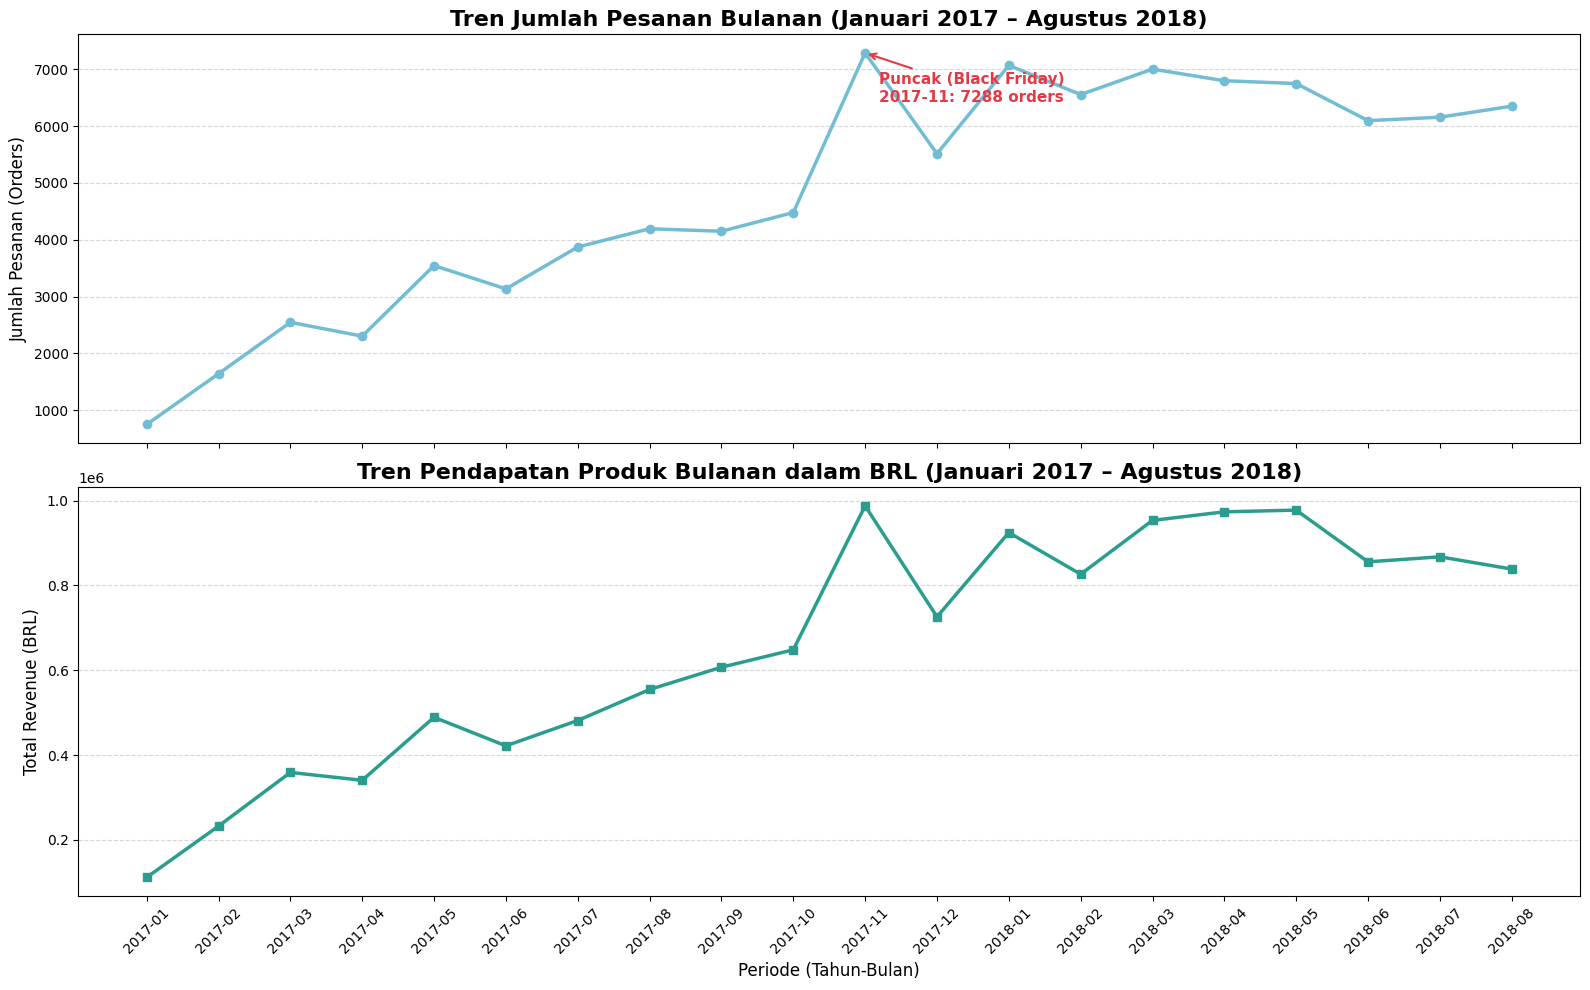

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 10), sharex=True)

# Grafik 1: Tren Jumlah Pesanan Bulanan
ax[0].plot(
    monthly_orders_df["year_month"],
    monthly_orders_df["total_orders"],
    marker="o",
    linewidth=2.5,
    color="#72BCD4"
)
ax[0].set_title("Tren Jumlah Pesanan Bulanan (Januari 2017 – Agustus 2018)", fontsize=16, fontweight="bold")
ax[0].set_ylabel("Jumlah Pesanan (Orders)", fontsize=12)
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# Highlight titik tertinggi (November 2017)
max_order_row = monthly_orders_df.loc[monthly_orders_df["total_orders"].idxmax()]
ax[0].annotate(
    f"Puncak (Black Friday)\n{max_order_row['year_month']}: {max_order_row['total_orders']} orders",
    xy=(max_order_row["year_month"], max_order_row["total_orders"]),
    xytext=(10, -35),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#E63946", lw=1.5),
    fontsize=11,
    fontweight="bold",
    color="#E63946"
)

# Grafik 2: Tren Total Revenue Produk Bulanan (BRL)
ax[1].plot(
    monthly_orders_df["year_month"],
    monthly_orders_df["product_revenue"],
    marker="s",
    linewidth=2.5,
    color="#2A9D8F"
)
ax[1].set_title("Tren Pendapatan Produk Bulanan dalam BRL (Januari 2017 – Agustus 2018)", fontsize=16, fontweight="bold")
ax[1].set_xlabel("Periode (Tahun-Bulan)", fontsize=12)
ax[1].set_ylabel("Total Revenue (BRL)", fontsize=12)
ax[1].tick_params(axis="x", rotation=45)
ax[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

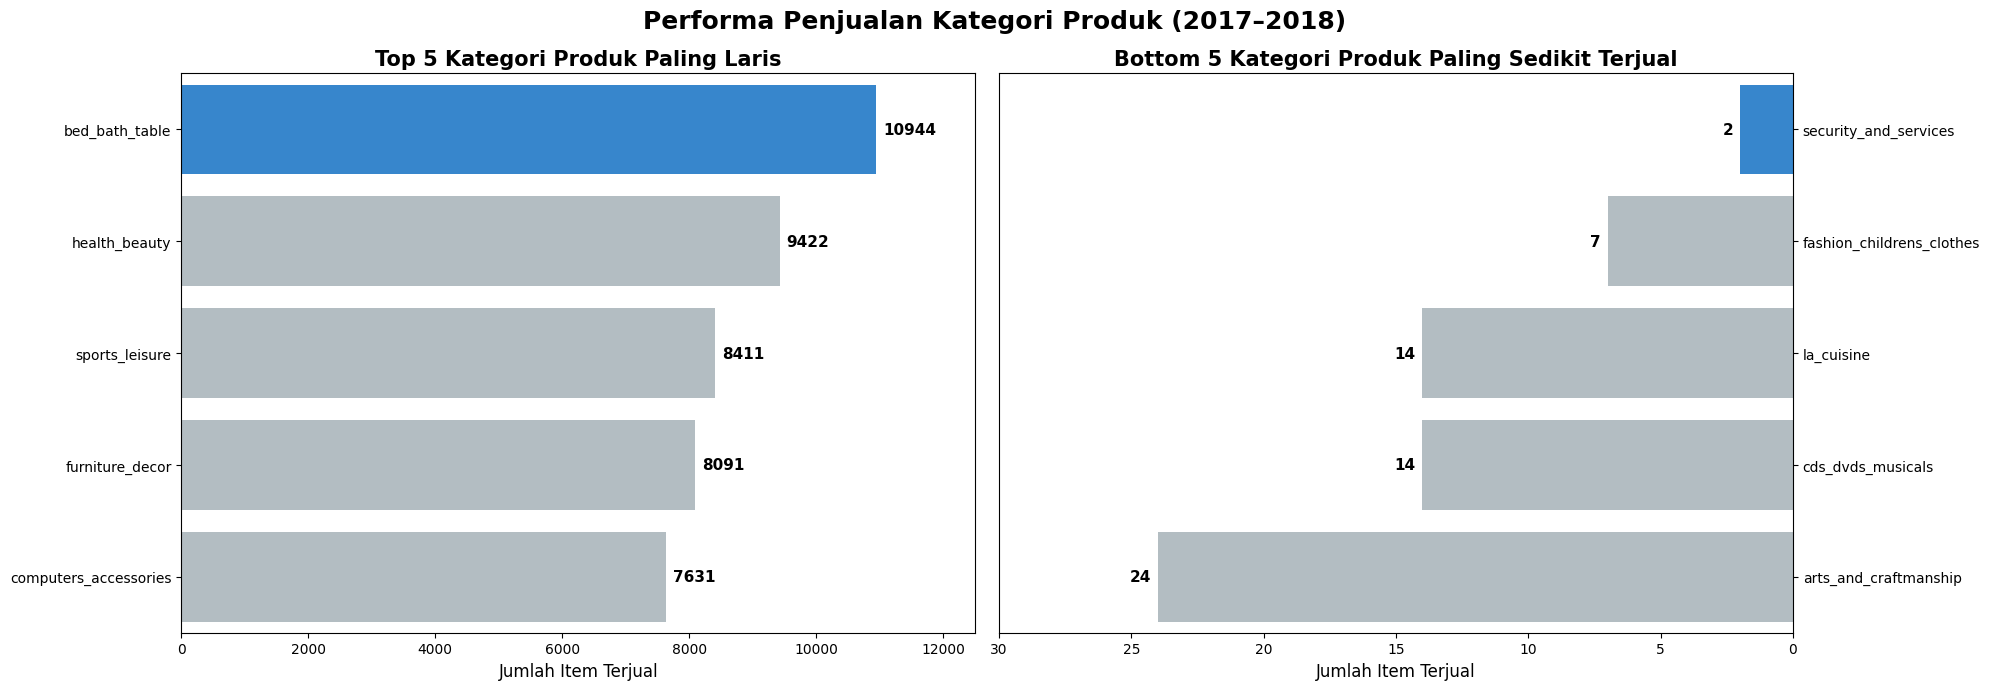

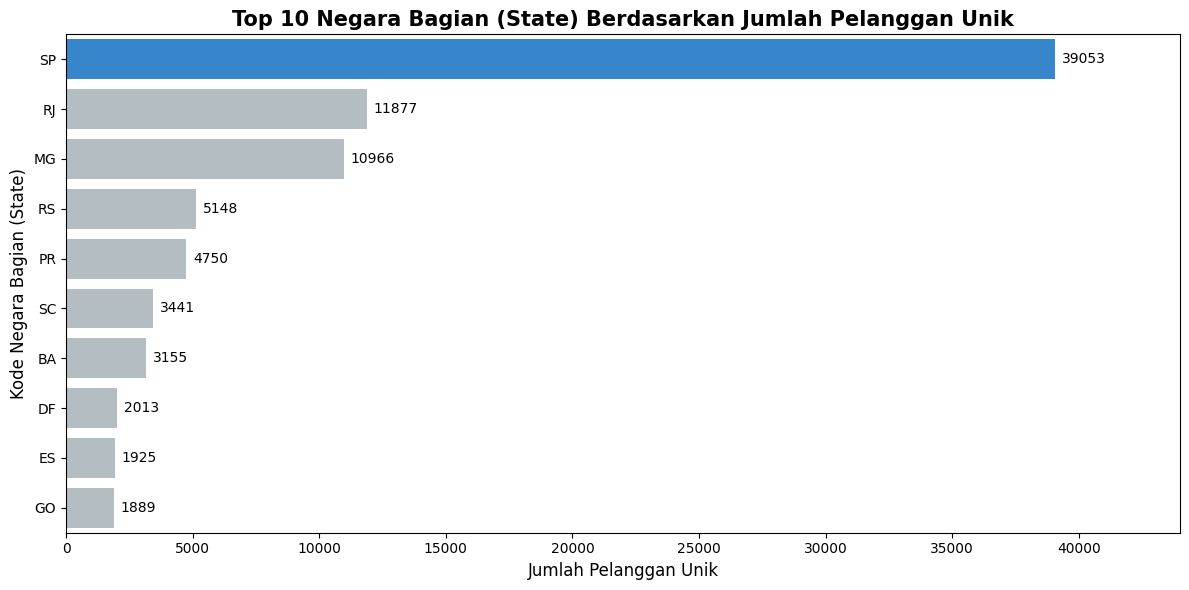

In [12]:
# Visualisasi 2A: Best & Worst Performing Product Categories
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))

colors_highlight = ["#1E88E5", "#B0BEC5", "#B0BEC5", "#B0BEC5", "#B0BEC5"]

# Top 5 Kategori Terlaris
top5_cat = category_orders_df.sort_values(by="items_sold", ascending=False).head(5)
sns.barplot(
    x="items_sold",
    y="product_category_name_english",
    hue="product_category_name_english",
    data=top5_cat,
    palette=colors_highlight,
    legend=False,
    ax=ax[0]
)
ax[0].set_title("Top 5 Kategori Produk Paling Laris", loc="center", fontsize=15, fontweight="bold")
ax[0].set_xlabel("Jumlah Item Terjual", fontsize=12)
ax[0].set_ylabel(None)
for container in ax[0].containers:
    ax[0].bar_label(container, padding=5, fontsize=11, fontweight="bold")
ax[0].set_xlim(0, 12500)

# Bottom 5 Kategori Terendah
bottom5_cat = category_orders_df.sort_values(by="items_sold", ascending=True).head(5)
sns.barplot(
    x="items_sold",
    y="product_category_name_english",
    hue="product_category_name_english",
    data=bottom5_cat,
    palette=colors_highlight,
    legend=False,
    ax=ax[1]
)
ax[1].set_title("Bottom 5 Kategori Produk Paling Sedikit Terjual", loc="center", fontsize=15, fontweight="bold")
ax[1].set_xlabel("Jumlah Item Terjual", fontsize=12)
ax[1].set_ylabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
for container in ax[1].containers:
    ax[1].bar_label(container, padding=5, fontsize=11, fontweight="bold")
ax[1].set_xlim(30, 0)

plt.suptitle("Performa Penjualan Kategori Produk (2017–2018)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

# Visualisasi 2B: Top 10 Negara Bagian (State) dengan Pelanggan Terbanyak
plt.figure(figsize=(12, 6))
top10_state = state_customers_df.sort_values(by="total_customers", ascending=False).head(10)
colors_state = ["#1E88E5"] + ["#B0BEC5"] * 9
ax_state = sns.barplot(
    x="total_customers",
    y="customer_state",
    hue="customer_state",
    data=top10_state,
    palette=colors_state,
    legend=False
)
for container in ax_state.containers:
    ax_state.bar_label(container, padding=5, fontsize=10)
plt.xlim(0, 44000)
plt.title("Top 10 Negara Bagian (State) Berdasarkan Jumlah Pelanggan Unik", fontsize=15, fontweight="bold")
plt.xlabel("Jumlah Pelanggan Unik", fontsize=12)
plt.ylabel("Kode Negara Bagian (State)", fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- **Pertanyaan 1:** Grafik *time-series* menunjukkan tren pertumbuhan positif sepanjang tahun 2017 yang mencapai puncaknya pada **November 2017 (7.288 order)** berkat kampanye *Black Friday*, kemudian bertahan stabil di level tinggi (6.000–7.100 order/bulan) hingga Agustus 2018.
- **Pertanyaan 2:** Penerapan prinsip desain warna kontras memperjelas bahwa kategori **`bed_bath_table`** mendominasi penjualan secara signifikan dibanding kategori lain, sementara dari sisi geografis, negara bagian **São Paulo (SP)** menyumbang porsi pelanggan terbesar yang jauh melampaui negara bagian lainnya.

## Analisis Lanjutan (Opsional): RFM Analysis & Customer Segmentation
Tujuan dari penerapan **RFM Analysis (*Recency, Frequency, Monetary*)** dan pengelompokan segmen pelanggan (*Manual Grouping* tanpa algoritma *Machine Learning*) ini adalah untuk memetakan tingkat loyalitas serta nilai kontribusi tiap pelanggan unik (`customer_unique_id`), sehingga perusahaan dapat menyusun strategi retensi yang tepat sasaran.

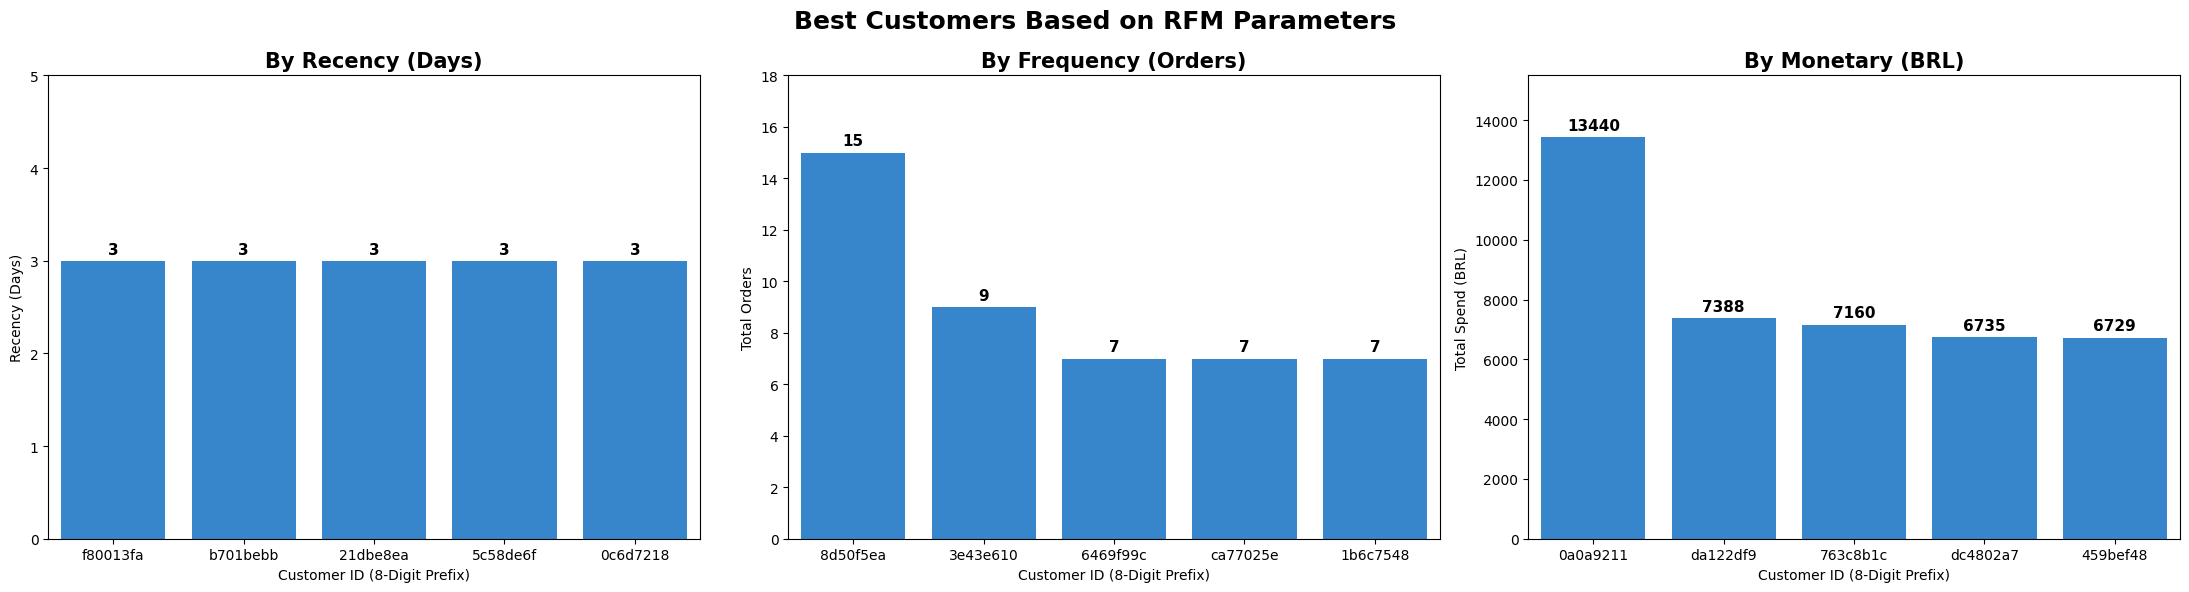

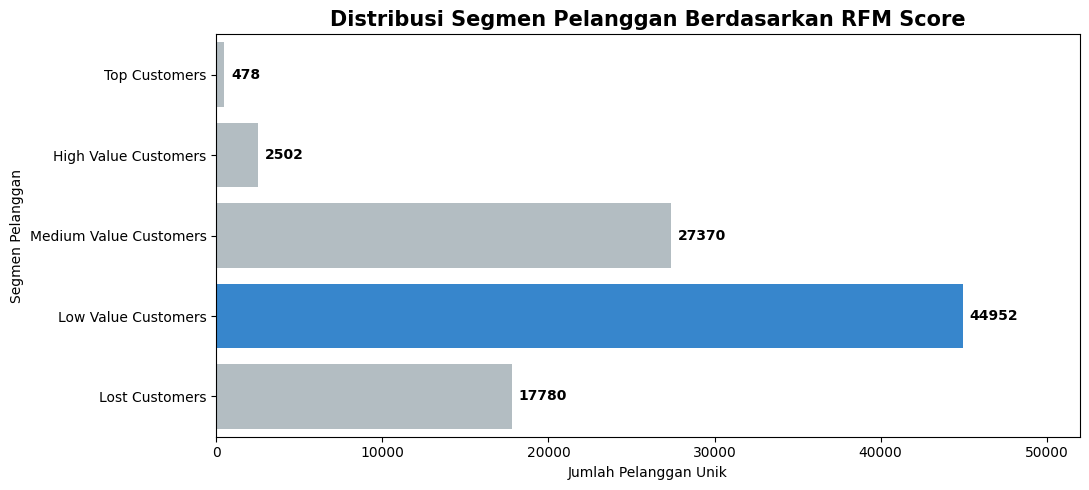

In [13]:
# 1. Menghitung nilai Recency, Frequency, dan Monetary per customer_unique_id
rfm_df = all_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})
rfm_df.columns = ["customer_unique_id", "max_order_timestamp", "frequency", "monetary"]

# Menghitung Recency dalam satuan hari (ditambah 1 hari dari batas akhir periode analisis: 1 September 2018)
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
reference_date = pd.to_datetime("2018-09-01").date()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (reference_date - x).days)

# Membuat ID pendek (8 karakter awal) agar label sumbu X rapi saat divisualisasikan
rfm_df["short_id"] = rfm_df["customer_unique_id"].str[:8]

# 2. Visualisasi Top 5 Pelanggan Berdasarkan Parameter R, F, dan M
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))
colors_rfm = ["#1E88E5"] * 5

top5_r = rfm_df.sort_values(by="recency", ascending=True).head(5)
sns.barplot(y="recency", x="short_id", hue="short_id", data=top5_r, palette=colors_rfm, legend=False, ax=ax[0])
ax[0].set_title("By Recency (Days)", fontsize=15, fontweight="bold")
ax[0].set_xlabel("Customer ID (8-Digit Prefix)")
ax[0].set_ylabel("Recency (Days)")
ax[0].set_ylim(0, 5)
for container in ax[0].containers:
    ax[0].bar_label(container, padding=3, fontsize=11, fontweight="bold")

top5_f = rfm_df.sort_values(by="frequency", ascending=False).head(5)
sns.barplot(y="frequency", x="short_id", hue="short_id", data=top5_f, palette=colors_rfm, legend=False, ax=ax[1])
ax[1].set_title("By Frequency (Orders)", fontsize=15, fontweight="bold")
ax[1].set_xlabel("Customer ID (8-Digit Prefix)")
ax[1].set_ylabel("Total Orders")
ax[1].set_ylim(0, 18)
for container in ax[1].containers:
    ax[1].bar_label(container, padding=3, fontsize=11, fontweight="bold")

top5_m = rfm_df.sort_values(by="monetary", ascending=False).head(5)
sns.barplot(y="monetary", x="short_id", hue="short_id", data=top5_m, palette=colors_rfm, legend=False, ax=ax[2])
ax[2].set_title("By Monetary (BRL)", fontsize=15, fontweight="bold")
ax[2].set_xlabel("Customer ID (8-Digit Prefix)")
ax[2].set_ylabel("Total Spend (BRL)")
ax[2].set_ylim(0, 15500)
for container in ax[2].containers:
    ax[2].bar_label(container, fmt="%.0f", padding=3, fontsize=11, fontweight="bold")

plt.suptitle("Best Customers Based on RFM Parameters", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. Menghitung RFM Score & Manual Grouping (Customer Segmentation)
rfm_df["r_rank"] = rfm_df["recency"].rank(ascending=False)
rfm_df["f_rank"] = rfm_df["frequency"].rank(ascending=True)
rfm_df["m_rank"] = rfm_df["monetary"].rank(ascending=True)

rfm_df["r_rank_norm"] = (rfm_df["r_rank"] / rfm_df["r_rank"].max()) * 100
rfm_df["f_rank_norm"] = (rfm_df["f_rank"] / rfm_df["f_rank"].max()) * 100
rfm_df["m_rank_norm"] = (rfm_df["m_rank"] / rfm_df["m_rank"].max()) * 100

rfm_df["RFM_score"] = (0.15 * rfm_df["r_rank_norm"] + 0.28 * rfm_df["f_rank_norm"] + 0.57 * rfm_df["m_rank_norm"]) * 0.05
rfm_df["RFM_score"] = rfm_df["RFM_score"].round(2)

rfm_df["customer_segment"] = np.where(
    rfm_df["RFM_score"] > 4.5, "Top Customers",
    np.where(
        rfm_df["RFM_score"] > 4.0, "High Value Customers",
        np.where(
            rfm_df["RFM_score"] > 3.0, "Medium Value Customers",
            np.where(rfm_df["RFM_score"] > 1.6, "Low Value Customers", "Lost Customers")
        )
    )
)

segment_counts_df = rfm_df.groupby(by="customer_segment", as_index=False, observed=False).agg({"customer_unique_id": "count"})
segment_counts_df.rename(columns={"customer_unique_id": "customer_count"}, inplace=True)
segment_order = ["Top Customers", "High Value Customers", "Medium Value Customers", "Low Value Customers", "Lost Customers"]
segment_counts_df["customer_segment"] = pd.Categorical(segment_counts_df["customer_segment"], categories=segment_order, ordered=True)
segment_counts_df.sort_values(by="customer_segment", inplace=True)

plt.figure(figsize=(11, 5))
colors_seg = ["#B0BEC5", "#B0BEC5", "#B0BEC5", "#1E88E5", "#B0BEC5"]
ax_seg = sns.barplot(
    x="customer_count",
    y="customer_segment",
    hue="customer_segment",
    data=segment_counts_df,
    palette=colors_seg,
    legend=False
)
for container in ax_seg.containers:
    ax_seg.bar_label(container, padding=5, fontsize=10, fontweight="bold")
plt.xlim(0, 52000)
plt.title("Distribusi Segmen Pelanggan Berdasarkan RFM Score", fontsize=15, fontweight="bold")
plt.xlabel("Jumlah Pelanggan Unik")
plt.ylabel("Segmen Pelanggan")
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- **Perilaku Repeat Order (*Frequency*):** Mayoritas mutlak pelanggan (~97%) hanya berbelanja sebanyak 1 kali (`frequency = 1`), namun pelanggan paling loyal tercatat melakukan hingga 15 kali pemesanan berulang, dan pelanggan dengan nilai *Monetary* tertinggi menghabiskan hingga 13.440 BRL.
- **Distribusi Segmen RFM:** Segmen terbesar berada pada kategori **Low Value Customers** dan **Medium Value Customers**, yang mengindikasikan tingginya akuisisi pelanggan baru namun masih rendahnya tingkat retensi (*repeat order*) setelah transaksi pertama selesai.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Tren jumlah pesanan dan pendapatan bulanan E-Commerce Olist sepanjang Januari 2017 hingga Agustus 2018 mengalami pertumbuhan yang sangat kuat pada tahun 2017 dan mencapai rekor tertingginya pada **November 2017** dengan **7.288 pesanan terkirim** serta pendapatan produk sebesar **987.648,07 BRL** (didorong oleh momentum promosi *Black Friday*). Memasuki Januari hingga Agustus 2018, volume transaksi mampu bertahan stabil di angka 6.000 hingga 7.100 pesanan per bulan.
- **Conclusion pertanyaan 2:** Kategori produk dengan volume penjualan tertinggi selama periode 2017–2018 adalah **`bed_bath_table` (10.944 item)**, **`health_beauty` (9.422 item)**, dan **`sports_leisure` (8.411 item)**, sedangkan kategori dengan penjualan terendah adalah **`security_and_services` (2 item)** dan **`fashion_childrens_clothes` (7 item)**. Dari sisi demografi lokasi dan RFM, pelanggan sangat terpusat di negara bagian **São Paulo/SP (39.035 pelanggan unik)**, namun mayoritas pelanggan masih berada di segmen *Low–Medium Value* karena baru melakukan 1 kali transaksi.

**Rekomendasi Action Item:**
- **Persiapan Kapasitas & Kampanye Puncak Tahunan (Terkait Pertanyaan 1):** Meningkatkan ketersediaan stok barang minimal 30% dan menambah mitra kurir logistik menjelang bulan **November (Black Friday)**, serta mengadakan kampanye *Mid-Year Sale* pada kuartal kedua dan ketiga untuk memecah stagnasi pertumbuhan order bulanan.
- **Strategi Bundling Produk & Gudang Regional (Terkait Pertanyaan 2):** Memfokuskan penempatan stok produk kategori terlaris (`bed_bath_table`, `health_beauty`, dan `sports_leisure`) di pusat gudang distribusi wilayah **São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG)** guna memangkas ongkos kirim dan mempercepat waktu pengantaran, sekaligus membuat paket *cross-selling/bundling* untuk mengangkat produk yang kurang laku.
- **Program Retensi Pasca-Pembelian Pertama (Terkait Analisis RFM):** Memberikan *voucher cashback* otomatis atau diskon ongkos kirim khusus untuk pembelian kedua (berlaku 30 hari setelah pesanan pertama berstatus *delivered*) guna mendorong pelanggan *Low/Medium Value* agar melakukan *repeat order* dan naik kelas menjadi *High Value / Top Customers*.